<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## VAE

參考:
- Stanford CS236: Deep Generative Models I 2023
  - [Lecture 5 - VAEs](https://www.youtube.com/watch?v=MAGBUh77bNg)
  - [Lecture 6 - VAEs](https://www.youtube.com/watch?v=8cO61e_8oPY)

#### Latent Variable Model

- explicitly model latent factors using latent variables z
- typically, $\text {dim}(z) \ll \text {dim}(x)$
- $p(x|z)$ could be much simpler than $p(x)$

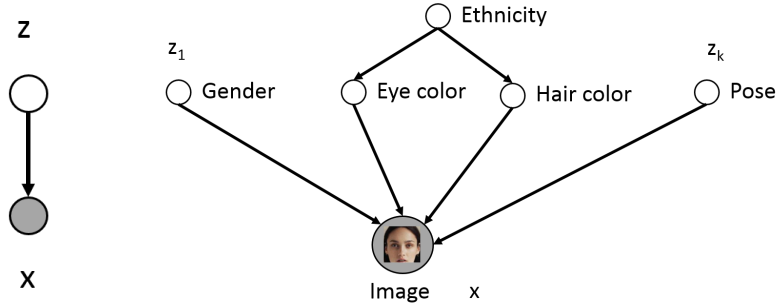

#### Deep Latent Variable Model

- $z \sim \mathcal{N}(0,I)$
- $p(x \mid z) = \mathcal{N}(\mu_\theta(z),\Sigma_\theta(z)) \quad$ where $\mu_\theta, \Sigma_\theta$ are neural networks


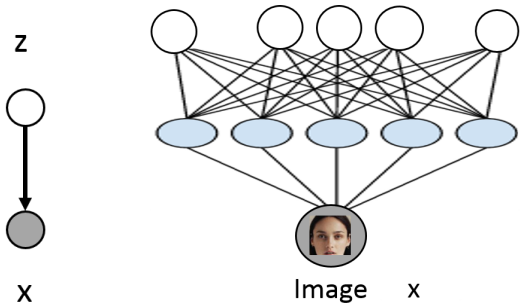

Bayes' Theorem:
- $\displaystyle p(z \mid x)=\frac{p(x \mid z) p(z)}{p(x)}$
- $p(z)$: prior
- $p(x \mid z)$: likelihood
- $p(z \mid x)$: posterior

- sampling: easy
- density distribution (evaluating $p(x)$): challenge

#### Mixture of Gaussians: a Shallow Latent Variable Model

- $z \sim \text {Categorical}(1,\dots,K)$
- $p(x \mid z=k) = \mathcal{N}(\mu_k,\Sigma_k)$
- clustering: $p(z \mid x)$ identifies the mixture component

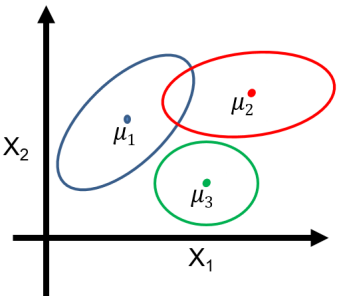

- combine simple models into a more complex and expressive one
- $p(x)=\sum_z p(x,z)=\sum_z p(z)p(x \mid z)=\sum_{k=1}^K p(z=k)\mathcal{N}(x;\mu_k,\Sigma_k)$
- allow us to define complex models $p(x)$ in terms of simpler building blocks $p(x \mid z)$

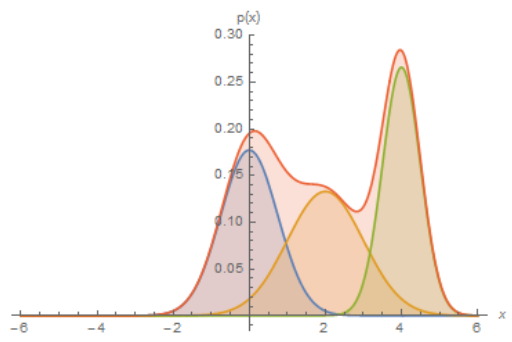

variational autoencoder marginal likelihood
- $p(x;\theta)=\int_{z} p(x,z;\theta)dz$: challange

#### Maximum Likelihood Learning

- $\ell(\theta;\mathcal{D})=\text {log}\prod_{x \in \mathcal{D}} p(x;\theta)=\sum_{x \in \mathcal{D}} \text {log}\ p(x;\theta)=\sum_{x \in \mathcal{D}} \text {log} \int_{z} p(x,z;\theta)dz$

Monte Carlo approximation with importance sampling
- try to sample the important completions ($z$) more often
- $\displaystyle p_\theta(x)=\sum_z p_\theta(x,z)=\sum_z \frac{q(z)}{q(z)} p_\theta(x,z)=\mathbb{E}_{z \sim q(z)}  \left[ \frac{p_\theta(x, z)}{q(z)} \right] \approx \frac{1}{k} \sum_{j=1}^k \frac{p_\theta(x,z^{(j)})}{q(z^{(j)})}$
- $q(z)$: Intuitively, frequently sample $z$ (completions) that are likely given $x$ under $p_\theta(x,z)$

log-likelihood
- $\displaystyle \mathbb{E}_{z^{(1)} \sim q(z)}  \left[ \text {log} \frac{p_\theta(x, z^{(1)})}{q(z^{(1)})} \right] \ne \text {log} \left( \mathbb{E}_{z^{(1)} \sim q(z)} \left[ \frac{p_\theta(x, z^{(1)})}{q(z^{(1)})} \right] \right)$

Jensen Inequality (for concave functions)
- $\text {log} \left( \mathbb{E}_{z \sim q(z)} \left[ f(z) \right] \right)=\text {log} \left( \sum_z q(z)f(z) \right) \ge \sum_z q(z)\ \text {log}\ f(z)=\mathbb{E}_{z \sim q(z)} \left[ log\ f(z) \right]$

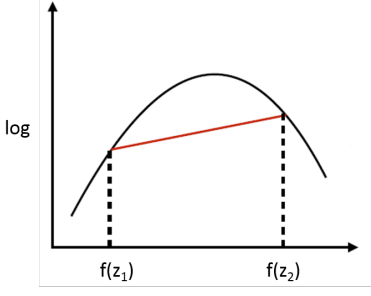

evidence lower bound (ELBO)
- $\displaystyle \text {log}\ p(x;\theta)=\text {log} \left( \mathbb{E}_{z \sim q(z)} \left[ \frac{p_\theta(x, z)}{q(z)} \right] \right) \ge \mathbb{E}_{z \sim q(z)} \left[ \text {log} \left( \frac{p_\theta(x, z)}{q(z)} \right) \right]$
- $\displaystyle \begin{array}[t]{l}
  \log p(x; \theta) \ge \sum_z q(z)\, \log \left( \frac{p_\theta(x,z)}{q(z)} \right) \\
  \qquad\qquad\quad= \sum_z q(z)\, \log p_\theta(x,z) - \sum_z q(z)\, \log q(z) \\
  \qquad\qquad\quad= \sum_z q(z)\, \log p_\theta(x,z) + H(q) \\
  \qquad\qquad\quad= \mathcal{L}(x; \theta; \phi)
  \end{array}$
- equality holds if $q=p(z \mid x;\theta)$
- Confirms our previous importance sampling intuition: we should
choose likely completions
- $\log\ p(x; \theta) = \text{ELBO} + D_{\text{KL}}(q(z) \,\|\, p(z \mid x; \theta))$
- $q$: auxiliary proposal distribution to infer the values of the latent variables $z$

variational inference (VI)
- reduces posterior inference to an optimization
problem
- $q(z; \phi)$: (tractable) probability distribution over the hidden
variables parameterized by $\phi$ (variational parameters)
- pick $\phi$ so that $q(z; \phi)$ is as close as possible to $p(z \mid x; \theta)$.

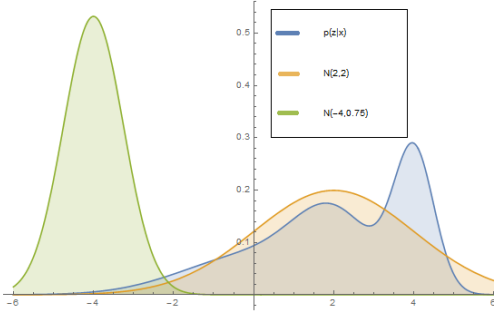

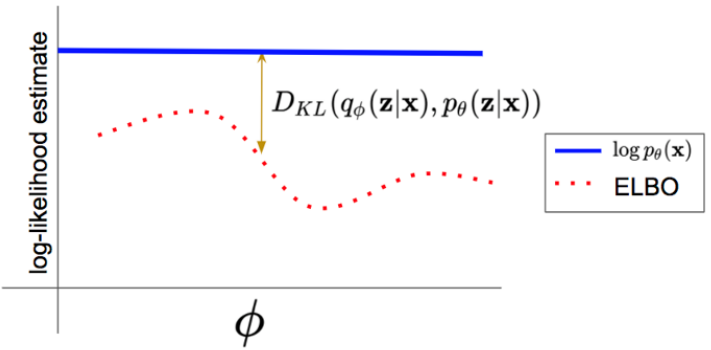

- jointly optimize over $\theta$ and $\phi$ to maximize the ELBO over a dataset

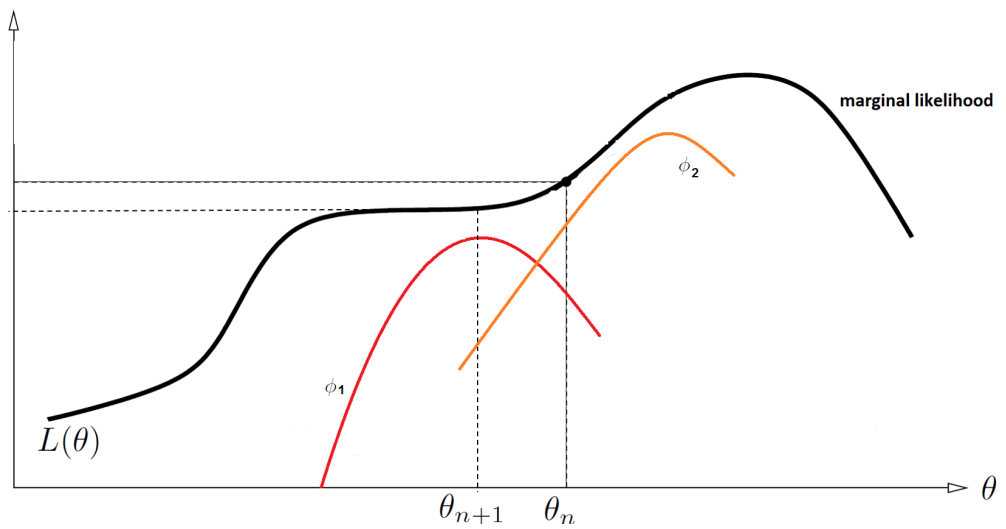

maximum likelihood learning (over the entire dataset):
- $\ell(\theta;\mathcal{D})=\sum_{x^i \in \mathcal{D}} \log\ p(x^i;\theta) \ge \sum_{x^i \in \mathcal{D}}\mathcal{L}(x^i; \theta; \phi^i)$
- $\max_\theta \ell(\theta;\mathcal{D}) \ge \max_{\theta,\phi^1,\dots,\phi^M} \sum_{x^i \in \mathcal{D}}\mathcal{L}(x^i; \theta; \phi^i)$

stochastic variational inference (SVI)
- $\mathcal{L}(x^i; \theta; \phi^i)=\mathbb{E}_{q(z;\phi^i)} \left[ \log\ p(z,x^i;\theta)-\log\ q(z;\phi^i) \right]$
- stochastic gradient ascent
- $\phi^i=\phi^i+\eta \nabla_{\phi^i}\mathcal{L}(x^i; \theta; \phi^i)$
- $\theta^i=\theta^i+\eta \nabla_{\theta^i}\mathcal{L}(x^i; \theta; \phi^i)$